In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("/content/StudentsPerformance_preprocessed.csv")

In [4]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Score,Percentage
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [5]:
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Score,Percentage
995,female,group E,master's degree,standard,completed,88,99,95,282,94.000000
996,male,group C,high school,free/reduced,none,62,55,55,172,57.333333
997,female,group C,high school,free/reduced,completed,59,71,65,195,65.000000
998,female,group D,some college,standard,completed,68,78,77,223,74.333333
999,female,group D,some college,free/reduced,none,77,86,86,249,83.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   object 
 1   race/ethnicity               1000 non-null   object 
 2   parental level of education  1000 non-null   object 
 3   lunch                        1000 non-null   object 
 4   test preparation course      1000 non-null   object 
 5   math score                   1000 non-null   int64  
 6   reading score                1000 non-null   int64  
 7   writing score                1000 non-null   int64  
 8   Total Score                  1000 non-null   int64  
 9   Percentage                   1000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 78.3+ KB


In [7]:
df.describe()

,math score,reading score,writing score,Total Score,Percentage
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,203.312000,67.770667
std,15.16308,14.600192,15.195657,42.771978,14.257326
min,0.00000,17.000000,10.000000,27.000000,9.000000
25%,57.00000,59.000000,57.750000,175.000000,58.333333
50%,66.00000,70.000000,69.000000,205.000000,68.333333
75%,77.00000,79.000000,79.000000,233.000000,77.666667
max,100.00000,100.000000,100.000000,300.000000,100.000000


In [8]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'Total Score', 'Percentage'],
      dtype='object')

In [9]:
df.shape

(1000, 10)

In [10]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0
Total Score,0
Percentage,0


In [11]:
score_columns=['math score','reading score','writing score']

In [12]:
df[score_columns].head()

,math score,reading score,writing score
0,72,72,74
1,69,90,88
2,90,95,93
3,47,57,44
4,76,78,75


In [13]:
demographic_columns=['gender','race/ethnicity','parental level of education','lunch','test preparation course']
df[demographic_columns].head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course
0,female,group B,bachelor's degree,standard,none
1,female,group C,some college,standard,completed
2,female,group B,master's degree,standard,none
3,male,group A,associate's degree,free/reduced,none
4,male,group C,some college,standard,none


In [15]:
df['gender'].unique()

array(['female', 'male'], dtype=object)

In [16]:
df['parental level of education'].unique()

array(["bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'],
      dtype=object)

In [17]:
df['lunch'].unique()

array(['standard', 'free/reduced'], dtype=object)

In [18]:
df['test preparation course'].unique()

array(['none', 'completed'], dtype=object)

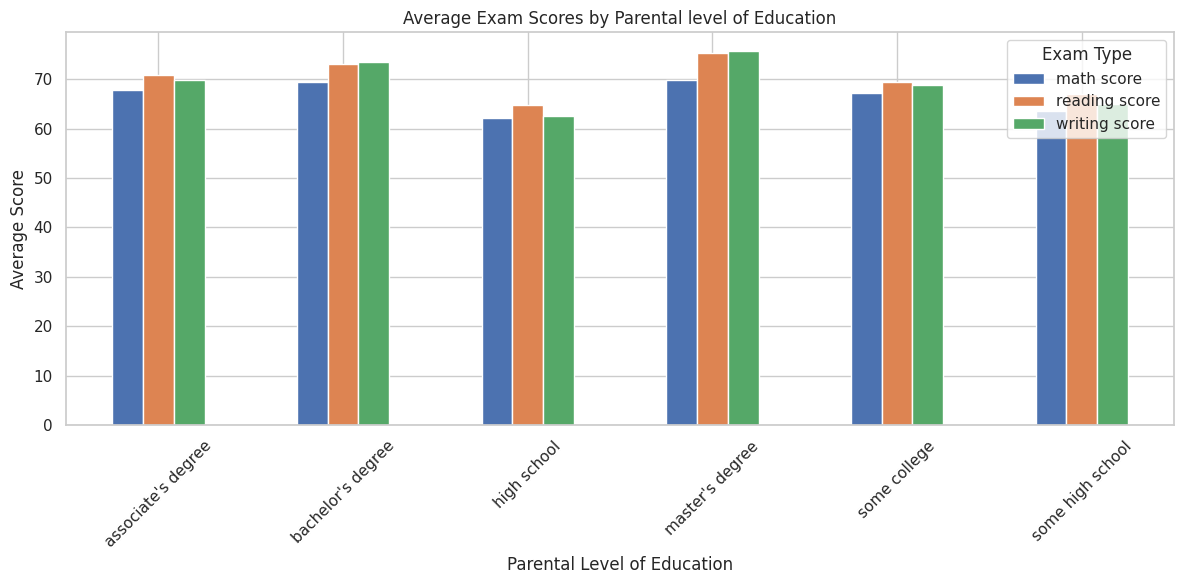

In [19]:
parental_score = df.groupby('parental level of education')[score_columns].mean()
parental_score.plot(kind='bar', figsize=(12,6))
plt.title('Average Exam Scores by Parental level of Education')
plt.xlabel('Parental Level of Education')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.legend(title='Exam Type')
plt.tight_layout()
plt.show()

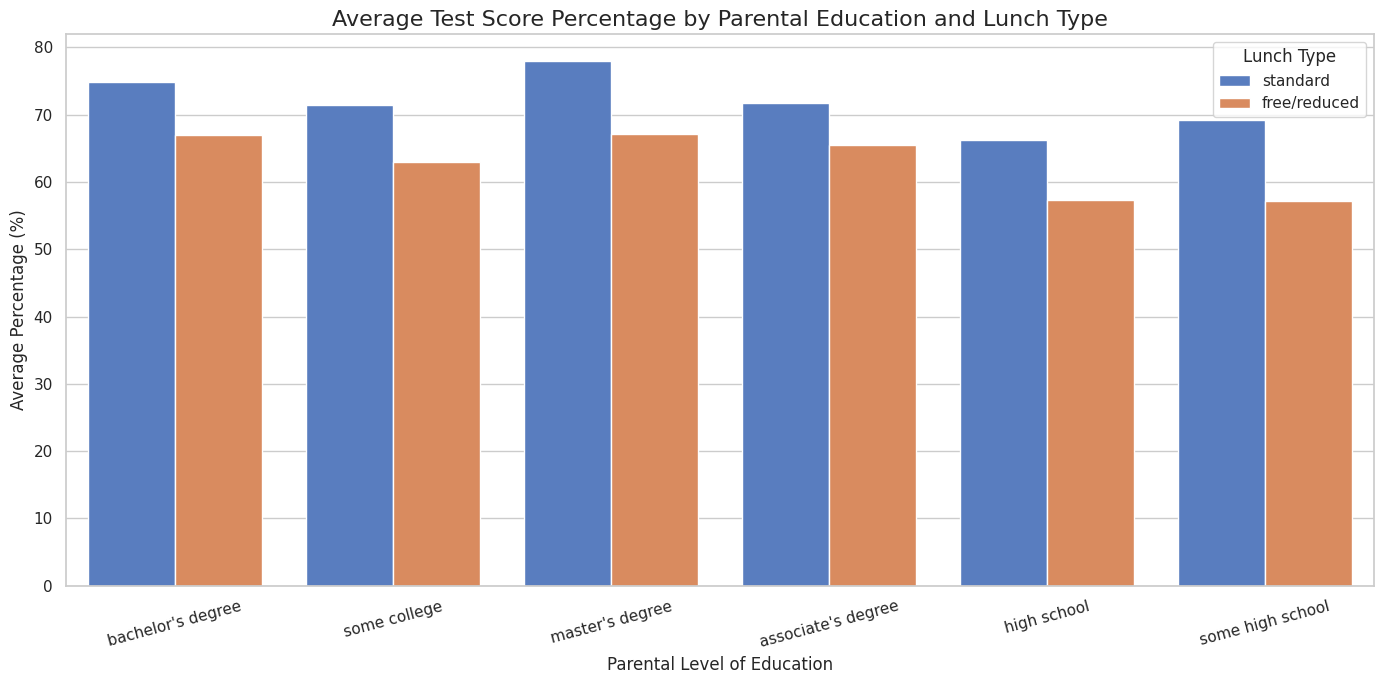

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 7))
sns.barplot(
    x='parental level of education',
    y='Percentage',
    hue='lunch',
    data=df,
    estimator=np.mean,
    errorbar=None,
    palette='muted'
)

plt.title('Average Test Score Percentage by Parental Education and Lunch Type', fontsize=16)
plt.xlabel('Parental Level of Education', fontsize=12)
plt.ylabel('Average Percentage (%)', fontsize=12)
plt.xticks(rotation=15)
plt.legend(title='Lunch Type', loc='upper right')
plt.tight_layout()

plt.show()

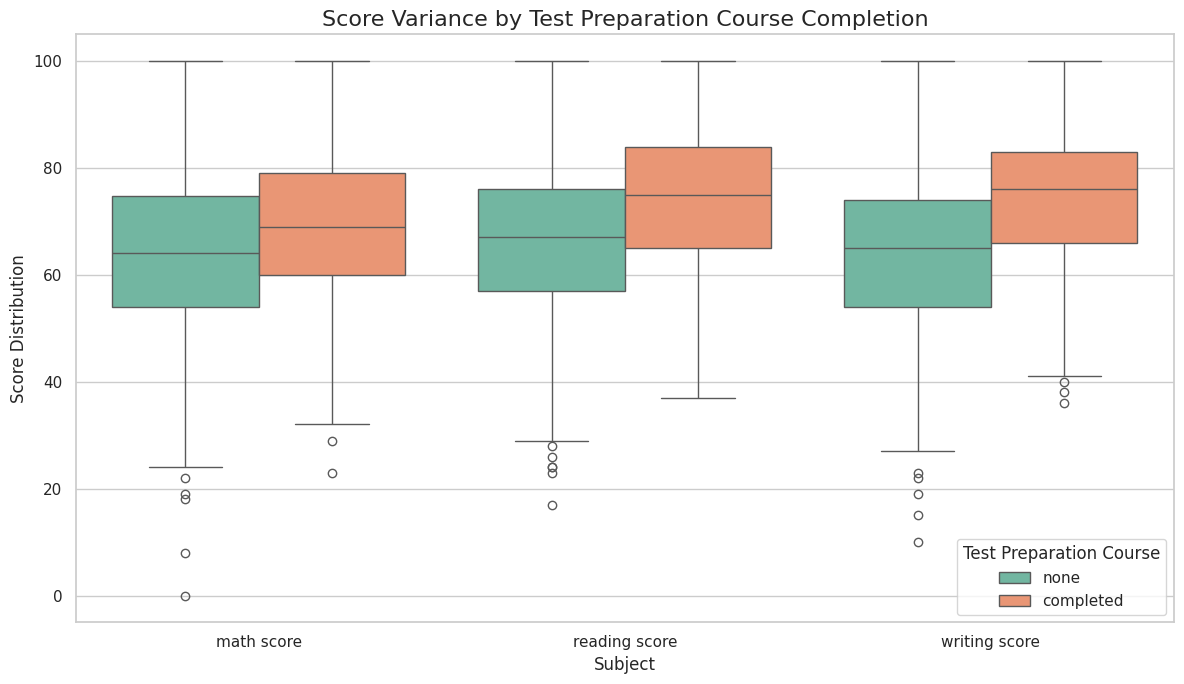

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

score_melted = df.melt(
    id_vars=['test preparation course'],
    value_vars=['math score', 'reading score', 'writing score'],
    var_name='Subject',
    value_name='Score'
)

plt.figure(figsize=(12, 7))
sns.boxplot(
    x='Subject',
    y='Score',
    hue='test preparation course',
    data=score_melted,
    palette='Set2'
)
plt.title('Score Variance by Test Preparation Course Completion', fontsize=16)
plt.xlabel('Subject', fontsize=12)
plt.ylabel('Score Distribution', fontsize=12)
plt.legend(title='Test Preparation Course')
plt.tight_layout()

plt.show()

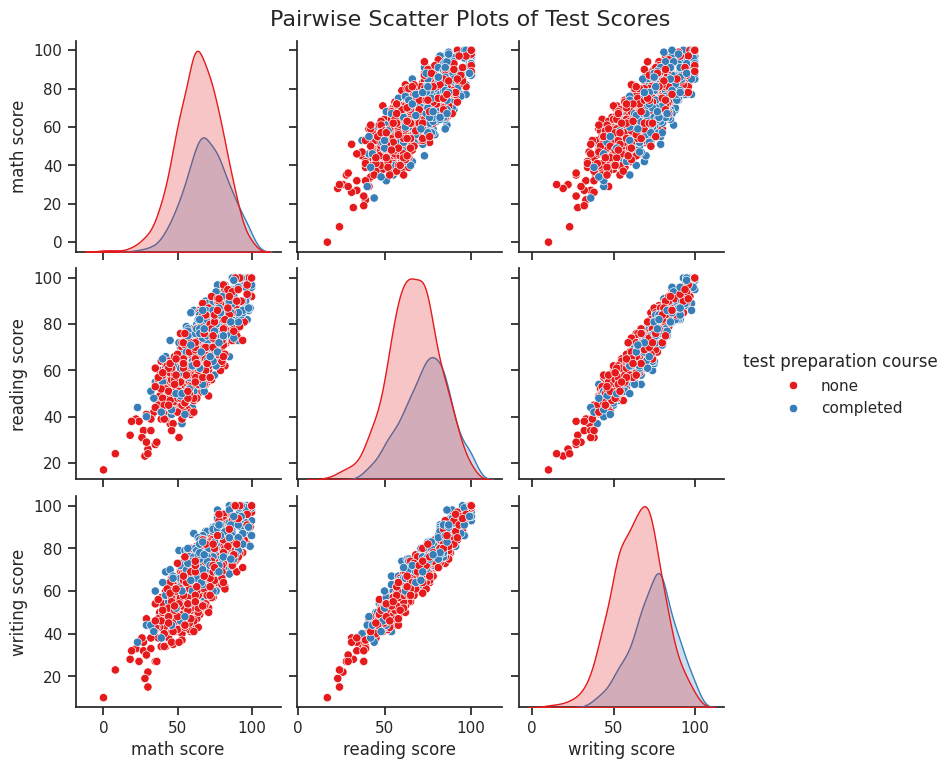

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="ticks")
pp = sns.pairplot(df[score_columns + ['test preparation course']], hue='test preparation course', palette='Set1', diag_kind='kde')
pp.fig.suptitle('Pairwise Scatter Plots of Test Scores', y=1.02, fontsize=16)
plt.show()

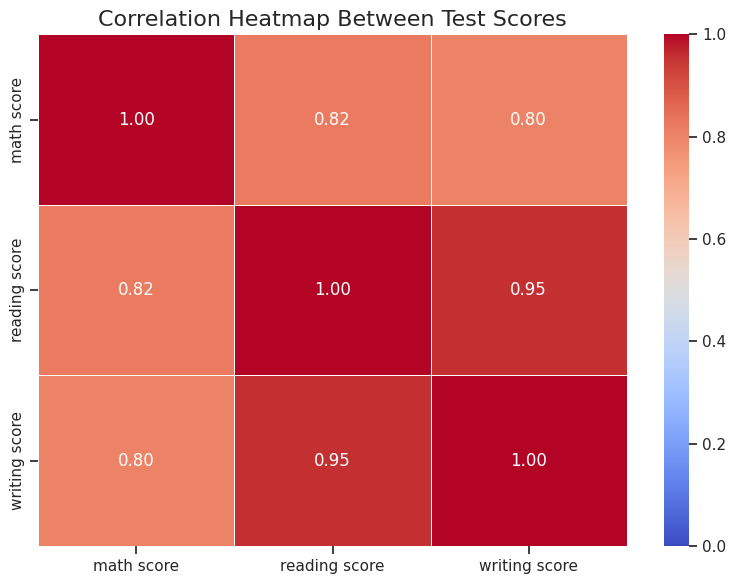

In [22]:
corr_matrix = df[score_columns].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap Between Test Scores', fontsize=16)
plt.tight_layout()
plt.show()